<a href="https://colab.research.google.com/github/omkarhegganna/ML2/blob/main/program6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Dataset Generation and Preparation
We will create a synthetic binary classification dataset using `scikit-learn` and split it into training and testing sets.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Generate a synthetic binary classification dataset
X, y = make_classification(
    n_samples=1500,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    random_state=42
)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")

Training set shape: (1200, 20)
Testing set shape: (300, 20)


### 2. Model Training
We will train three different ensemble models:
1. **Bagging Classifier** (using Random Forest Classifier)
2. **Boosting Classifier - AdaBoost**
3. **Boosting Classifier - Gradient Boosting**

In [2]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize classifiers
models = {
    'Random Forest (Bagging)': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost (Boosting)': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting (Boosting)': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Dictionary to store performance metrics
results = {}

# Train and evaluate each model
for name, model in models.items():
    # Fit model
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate metrics
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob)
    }

# Convert results to DataFrame for comparison
df_results = pd.DataFrame(results).T
display(df_results)

,Accuracy,Precision,Recall,F1-Score,ROC AUC
Random Forest (Bagging),0.943333,0.958621,0.926667,0.942373,0.980867
AdaBoost (Boosting),0.856667,0.874126,0.833333,0.853242,0.916756
Gradient Boosting (Boosting),0.930000,0.951049,0.906667,0.928328,0.977111


### 3. Performance Visualization and Comparison

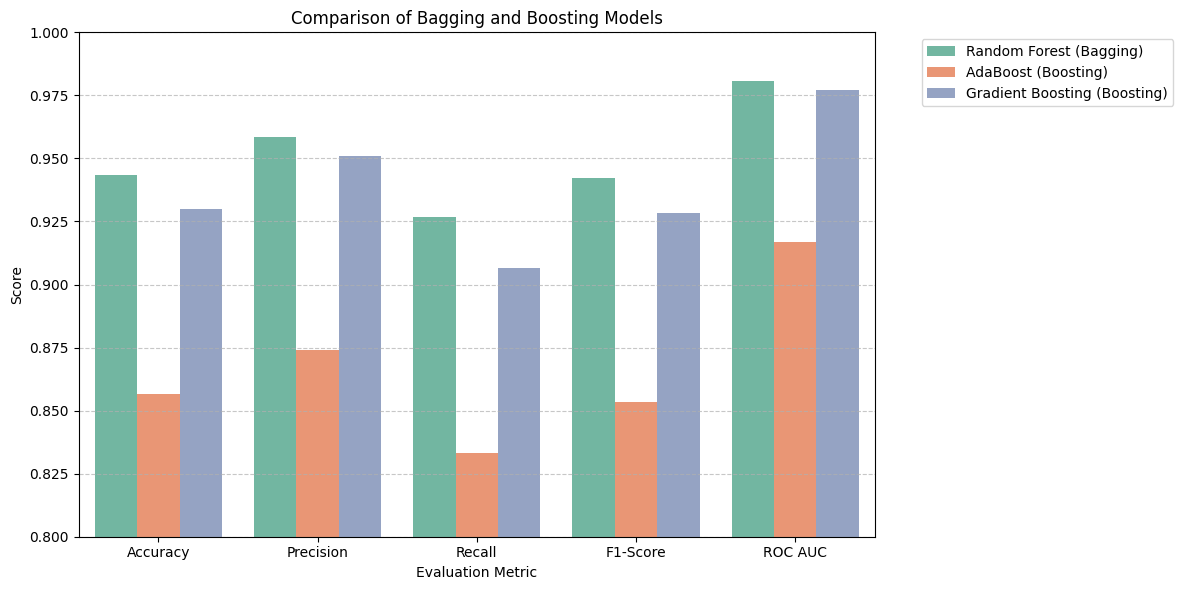

In [3]:
# Melt DataFrame for easy plotting with seaborn
df_plot = df_results.reset_index().rename(columns={'index': 'Model'})
df_melted = pd.melt(df_plot, id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted, palette='Set2')
plt.title('Comparison of Bagging and Boosting Models')
plt.ylim(0.8, 1.0) # Zooming in to highlight difference in performance
plt.ylabel('Score')
plt.xlabel('Evaluation Metric')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()